#  Bengali Sign Language Detection — CNN Assignment (FIXED)
### 6CS012 · Artificial Intelligence and Machine Learning · 2026


---
## Upload & Auto-Unzip Dataset


In [1]:
import os, zipfile
from google.colab import files

# ── 1. Upload zip file
print(' Please upload your dataset zip file ...')
uploaded = files.upload()

zip_name = [f for f in uploaded.keys() if f.endswith('.zip')][0]
print(f'Got: {zip_name}')

# ── 2. Unzip
EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(' Unzipping ... (this may take 1-2 minutes)')
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(EXTRACT_DIR)
print('Unzip done!')

# ── 3. Auto-find Train / Test folders
DATASET_PATH = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if 'Train' in dirs and 'Test' in dirs:
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise FileNotFoundError(' Train/Test folders not found inside zip!')

TRAIN_PATH = os.path.join(DATASET_PATH, 'Train')
TEST_PATH  = os.path.join(DATASET_PATH, 'Test')

print(f'\n Dataset root : {DATASET_PATH}')
print(f' Train folder : {TRAIN_PATH}')
print(f' Test folder  : {TEST_PATH}')


 Please upload your dataset zip file ...


Saving Sign Language Detection-20260428T073024Z-3-001.zip to Sign Language Detection-20260428T073024Z-3-001.zip
Got: Sign Language Detection-20260428T073024Z-3-001.zip
 Unzipping ... (this may take 1-2 minutes)
Unzip done!

 Dataset root : /content/dataset/Sign Language Detection
 Train folder : /content/dataset/Sign Language Detection/Train
 Test folder  : /content/dataset/Sign Language Detection/Test


---
## FIX 1 — Remove Corrupted Images


In [2]:
from PIL import Image
import os

MIN_SIZE_BYTES = 1024
removed_small  = 0
removed_broken = 0
kept           = 0

print(' Scanning for corrupted images ...')

for cls_folder in os.listdir(TRAIN_PATH):
    cls_path = os.path.join(TRAIN_PATH, cls_folder)
    if not os.path.isdir(cls_path):
        continue
    for img_file in os.listdir(cls_path):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        full_path = os.path.join(cls_path, img_file)

        # Check 1: too small → definitely corrupt
        if os.path.getsize(full_path) < MIN_SIZE_BYTES:
            os.remove(full_path)
            removed_small += 1
            continue

        # Check 2: try to open with PIL → catches broken JPEG headers
        try:
            with Image.open(full_path) as img:
                img.verify()     # verify does a quick integrity check
            kept += 1
        except Exception:
            os.remove(full_path)
            removed_broken += 1

print(f'\n   Removed (too small)  : {removed_small}')
print(f'   Removed (broken file) : {removed_broken}')
print(f'   Valid images kept     : {kept}')
print('\n Dataset cleaned! Now the model will train on real images only.')


 Scanning for corrupted images ...

   Removed (too small)  : 266
   Removed (broken file) : 0
   Valid images kept     : 10792

 Dataset cleaned! Now the model will train on real images only.


---
##Import All Libraries


In [3]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available     :', tf.config.list_physical_devices('GPU'))
print(' All libraries loaded!')


TensorFlow version: 2.20.0
GPU available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 All libraries loaded!


---
# PART A — CNNs from Scratch
## Section 1 · Data Understanding, Analysis & Visualization


In [4]:
classes     = sorted(os.listdir(TRAIN_PATH), key=lambda x: int(x))
NUM_CLASSES = len(classes)

class_counts = {}
for cls in classes:
    folder = os.path.join(TRAIN_PATH, cls)
    imgs   = [f for f in os.listdir(folder)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[int(cls)] = len(imgs)

test_imgs   = [f for f in os.listdir(TEST_PATH)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
total_train = sum(class_counts.values())

print('=' * 48)
print('         DATASET SUMMARY')
print('=' * 48)
print(f'  Dataset        : Bengali Sign Language')
print(f'  Task           : Multi-class Classification')
print(f'  Total Classes  : {NUM_CLASSES}')
print(f'  Training Images: {total_train} (after cleaning)')
print(f'  Test Images    : {len(test_imgs)}')
print(f'  Avg per Class  : {total_train // NUM_CLASSES}')
print(f'  Min per Class  : {min(class_counts.values())}')
print(f'  Max per Class  : {max(class_counts.values())}')
print('=' * 48)
print("""
 Dataset Description:
The Bengali Sign Language dataset contains hand gesture
images representing 38 classes (digits 0–37). Each class
is a separate hand gesture. We train a CNN to classify them.
""")


         DATASET SUMMARY
  Dataset        : Bengali Sign Language
  Task           : Multi-class Classification
  Total Classes  : 38
  Training Images: 10792 (after cleaning)
  Test Images    : 3
  Avg per Class  : 284
  Min per Class  : 239
  Max per Class  : 293

 Dataset Description:
The Bengali Sign Language dataset contains hand gesture
images representing 38 classes (digits 0–37). Each class
is a separate hand gesture. We train a CNN to classify them.



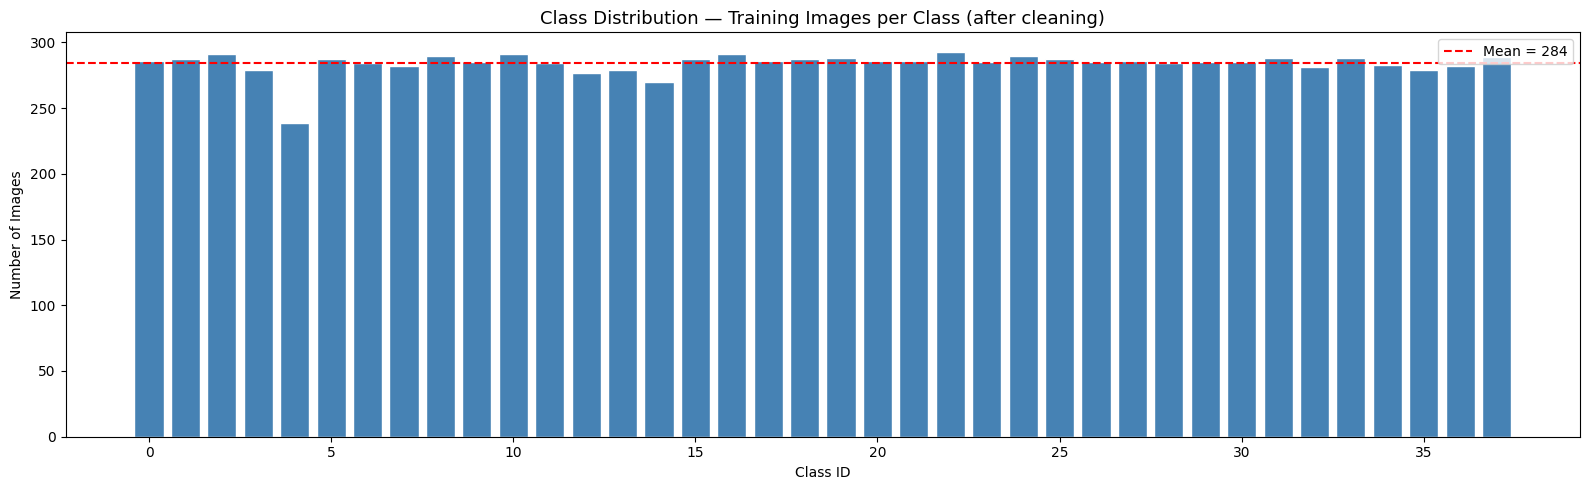

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
cls_ids = list(class_counts.keys())
counts  = list(class_counts.values())
ax.bar(cls_ids, counts, color='steelblue', edgecolor='white')
ax.axhline(np.mean(counts), color='red', linestyle='--',
           label=f'Mean = {np.mean(counts):.0f}')
ax.set_title('Class Distribution — Training Images per Class (after cleaning)', fontsize=13)
ax.set_xlabel('Class ID');  ax.set_ylabel('Number of Images')
ax.legend();  plt.tight_layout();  plt.show()


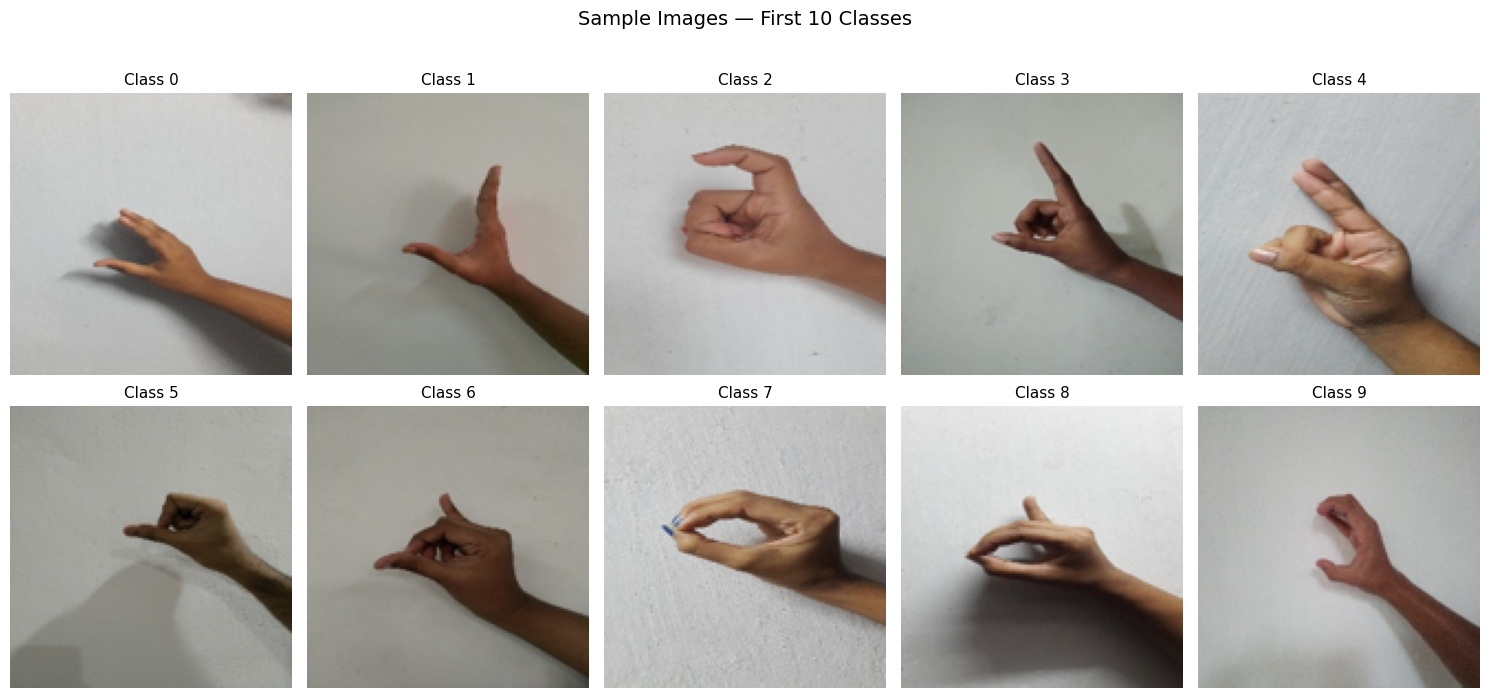

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()
for i, cls in enumerate(classes[:10]):
    folder   = os.path.join(TRAIN_PATH, cls)
    img_file = os.listdir(folder)[0]
    img      = Image.open(os.path.join(folder, img_file)).resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(f'Class {cls}', fontsize=11)
    axes[i].axis('off')
plt.suptitle('Sample Images — First 10 Classes', fontsize=14, y=1.02)
plt.tight_layout();  plt.show()


---
## Section 2 · Preprocessing & Data Augmentation

**Key settings:**
- Images resized to **64×64** (fast training)
- Pixels normalized: 0–255 → 0–1
- 80% train / 20% validation split
- **`shuffle=False` on val generator** ← this is the fix that was missing before


In [7]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20

# ── Training generator: WITH augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    validation_split   = VAL_SPLIT,
    horizontal_flip    = True,
    rotation_range     = 15,
    zoom_range         = 0.15,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
)

val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT,
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = 42
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = 42
)

print(f'Training batches  : {len(train_gen)}')
print(f'Validation batches: {len(val_gen)}')
print(f'Classes           : {train_gen.num_classes}')
print('\n val_gen has shuffle=False so evaluation labels always match predictions!')


Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Training batches  : 271
Validation batches: 67
Classes           : 38

 val_gen has shuffle=False so evaluation labels always match predictions!


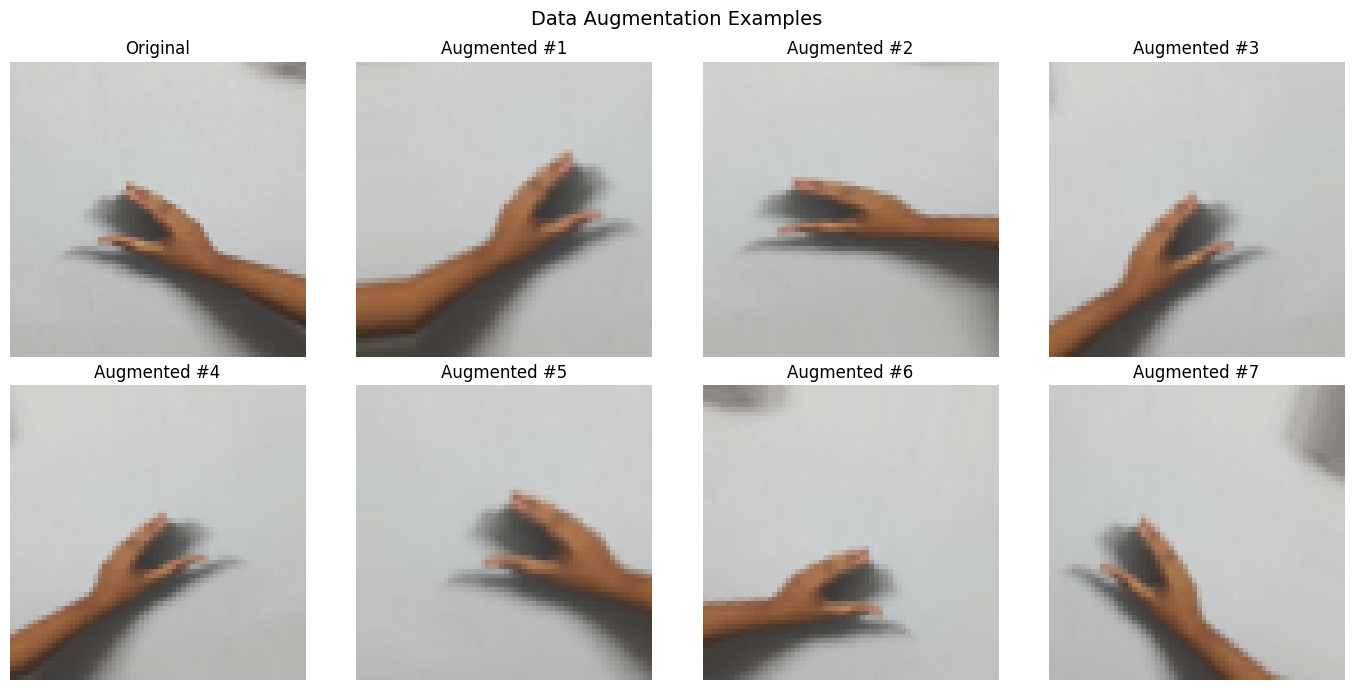

In [8]:
# Show augmentation examples on one image
sample_folder = os.path.join(TRAIN_PATH, classes[0])
sample_file   = os.listdir(sample_folder)[0]
sample_img    = Image.open(os.path.join(sample_folder, sample_file)).resize(IMG_SIZE)
sample_arr    = np.array(sample_img).reshape((1,) + np.array(sample_img).shape)

aug = ImageDataGenerator(
    horizontal_flip=True, rotation_range=20,
    zoom_range=0.2, width_shift_range=0.15, height_shift_range=0.15)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
axes[0].imshow(sample_img);  axes[0].set_title('Original');  axes[0].axis('off')
for i, batch in enumerate(aug.flow(sample_arr, batch_size=1), start=1):
    if i >= 8: break
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f'Augmented #{i}');  axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=14)
plt.tight_layout();  plt.show()


---
## Section 3 · Baseline CNN Model
**Architecture:** 3 Conv blocks → Flatten → 3 Dense layers → Softmax output


In [9]:
def build_baseline_model(num_classes, img_size=(64, 64, 3)):
    """
    Simple baseline CNN:
    3 Conv layers + 3 Dense layers — no regularization.
    """
    model = models.Sequential(name='Baseline_CNN')
    model.add(layers.Input(shape=img_size))

    # Block 1: 32 filters, detects basic edges and colours
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 2: 64 filters, detects more complex patterns
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 3: 128 filters, high-level features
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Flatten + 3 fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))   # FC1
    model.add(layers.Dense(256, activation='relu'))   # FC2
    model.add(layers.Dense(128, activation='relu'))   # FC3

    # Output: one probability per class
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,457,190 (17.00 MB)

 Trainable params: 4,457,190 (17.00 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=7,
                           restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=4, min_lr=1e-6, verbose=1)

print(' Training Baseline CNN ...')
start = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 25,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

baseline_time = time.time() - start
print(f'\n Training time: {baseline_time/60:.1f} minutes')


 Training Baseline CNN ...
Epoch 1/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.0232 - loss: 3.6394 - val_accuracy: 0.0266 - val_loss: 3.6374 - learning_rate: 0.0010
Epoch 2/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.0271 - loss: 3.6367 - val_accuracy: 0.0564 - val_loss: 3.5944 - learning_rate: 0.0010
Epoch 3/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.0816 - loss: 3.3683 - val_accuracy: 0.1306 - val_loss: 3.1274 - learning_rate: 0.0010
Epoch 4/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.1636 - loss: 2.9092 - val_accuracy: 0.1964 - val_loss: 2.8866 - learning_rate: 0.0010
Epoch 5/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.2532 - loss: 2.4881 - val_accuracy: 0.2668 - val_loss: 2.5839 - learning_rate: 0.0010
Epoch 6/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.3602 - loss: 2.0802 - val_accuracy: 0.3596 - val_loss: 2.2440 - learning_rate: 0.0010
Epoch 7/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/

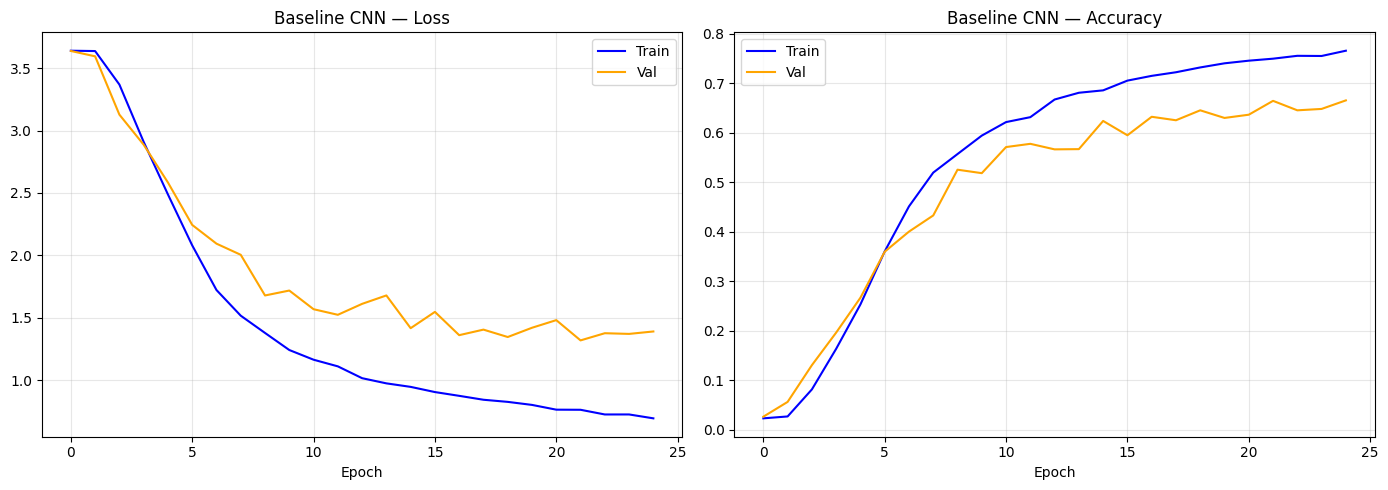

In [11]:
def plot_history(history, title='Training Curves'):
    """Plot loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],     label='Train', color='blue')
    ax1.plot(history.history['val_loss'], label='Val',   color='orange')
    ax1.set_title(f'{title} — Loss');  ax1.set_xlabel('Epoch')
    ax1.legend();  ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Val',   color='orange')
    ax2.set_title(f'{title} — Accuracy');  ax2.set_xlabel('Epoch')
    ax2.legend();  ax2.grid(True, alpha=0.3)
    plt.tight_layout();  plt.show()

plot_history(baseline_history, 'Baseline CNN')



Evaluating Baseline CNN ...

  Accuracy : 0.6642 (66.42%)

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.77      0.69        57
           1       0.65      0.84      0.73        57
           2       0.78      0.74      0.76        58
           3       0.86      0.66      0.75        56
           4       0.76      0.64      0.69        55
           5       0.51      0.69      0.58        55
           6       0.61      0.57      0.59        54
           7       0.87      0.47      0.61        57
           8       0.58      0.84      0.69        58
           9       0.62      0.70      0.66        57
          10       0.48      0.54      0.51        57
          11       0.77      0.40      0.53        57
          12       0.66      0.79      0.72        58
          13       0.69      0.67      0.68        57
          14       0.77      0.81      0.79        57
          15       0.67      0.64      0.65        5

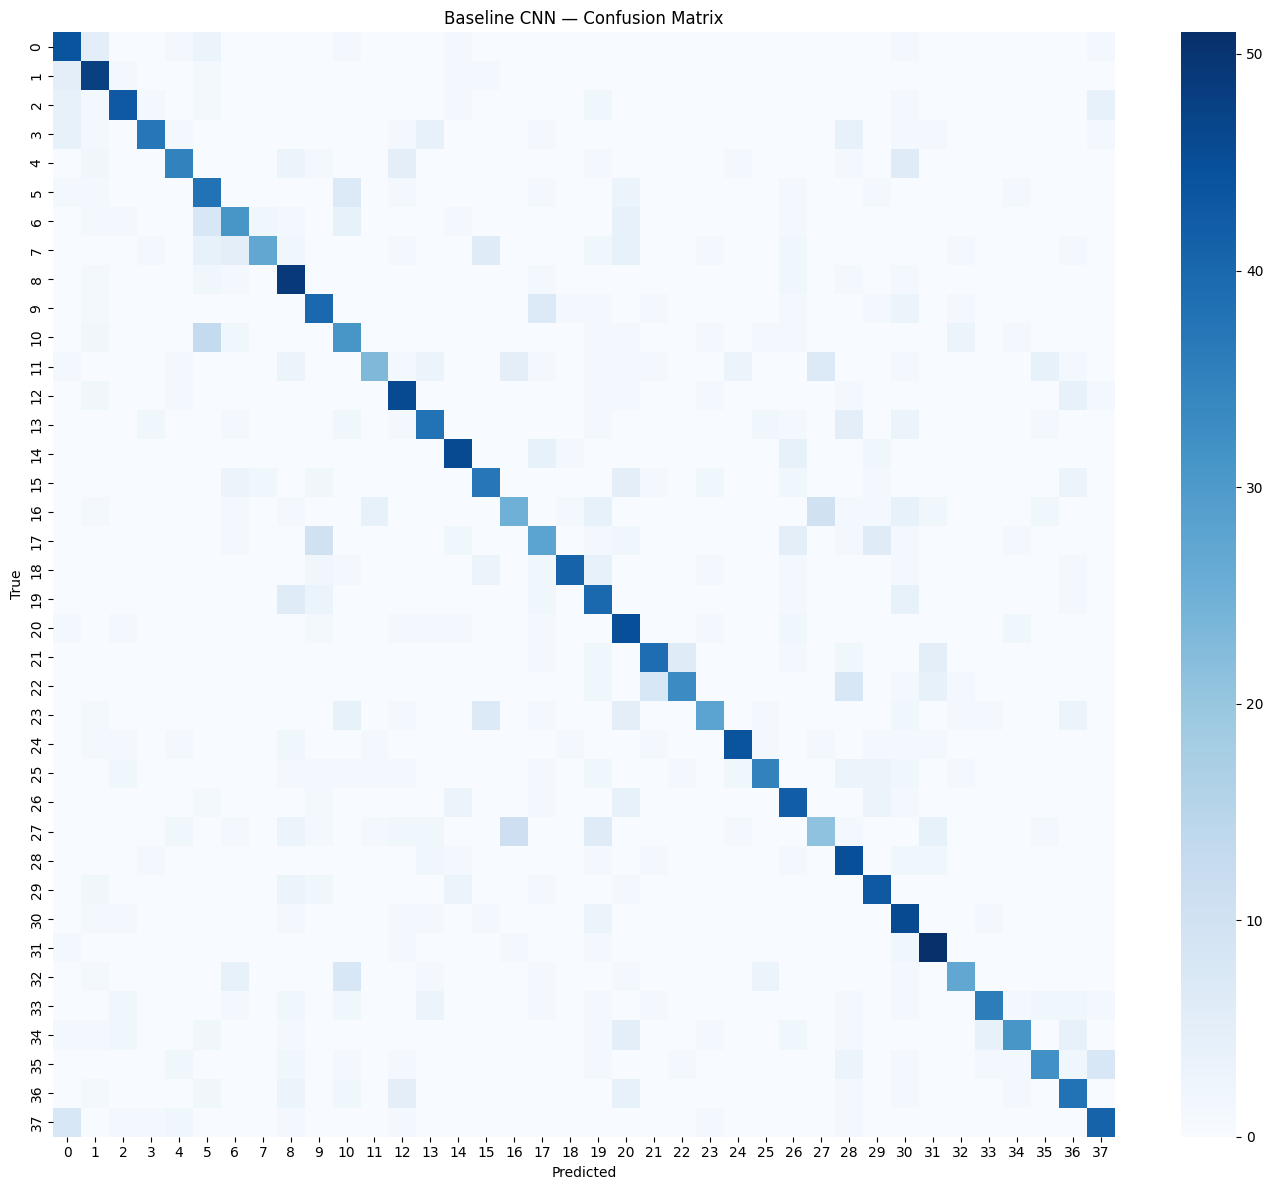

In [12]:
def evaluate_model(model, generator, model_name='Model'):
    """
    Evaluate model on a generator.
    IMPORTANT: generator must have shuffle=False for correct results!
    """
    print(f'\nEvaluating {model_name} ...')

    # Reset so we always start from image #1
    generator.reset()

    # Predict all batches
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    # True labels — works correctly because shuffle=False
    y_true = generator.classes

    # Trim in case the last batch was padded
    min_len = min(len(y_pred), len(y_true))
    y_pred  = y_pred[:min_len]
    y_true  = y_true[:min_len]

    acc = accuracy_score(y_true, y_pred)
    print(f'\n  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted');  plt.ylabel('True')
    plt.tight_layout();  plt.show()

    return acc


baseline_acc = evaluate_model(baseline_model, val_gen, 'Baseline CNN')


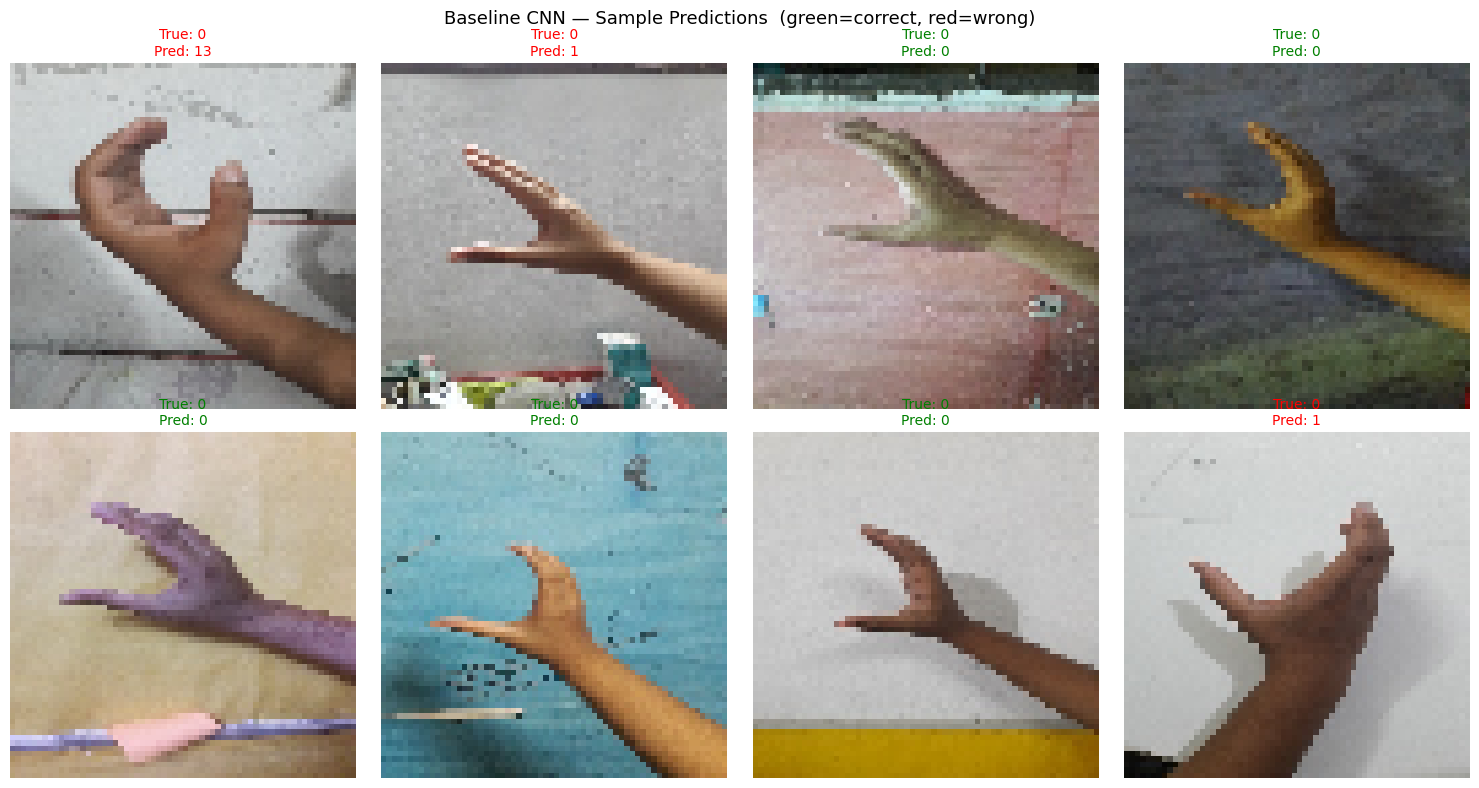

In [13]:
def show_predictions(model, generator, n=8, title='Predictions'):
    """Show n images with predicted vs true label."""
    generator.reset()
    imgs_batch, labels_batch = next(generator)
    preds    = model.predict(imgs_batch[:n], verbose=0)
    pred_ids = np.argmax(preds, axis=1)
    true_ids = np.argmax(labels_batch[:n], axis=1)
    idx2cls  = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(imgs_batch[i])
        ok    = pred_ids[i] == true_ids[i]
        color = 'green' if ok else 'red'
        axes[i].set_title(
            f'True: {idx2cls[true_ids[i]]}\nPred: {idx2cls[pred_ids[i]]}',
            color=color, fontsize=10)
        axes[i].axis('off')
    plt.suptitle(f'{title}  (green=correct, red=wrong)', fontsize=13)
    plt.tight_layout();  plt.show()

show_predictions(baseline_model, val_gen, title='Baseline CNN — Sample Predictions')


---
## Section 4 · Deeper CNN with Regularization
**Improvements:** 6 Conv blocks + Batch Normalization + Dropout + L2 weight penalty


In [19]:
def build_deeper_model(num_classes, img_size=(64, 64, 3), optimizer='adam'):
    """
    Deeper CNN with 6 conv blocks and regularization.
    optimizer: 'adam' or 'sgd'
    """
    L2 = regularizers.l2(1e-4)
    model = models.Sequential(name='Deeper_CNN')
    model.add(layers.Input(shape=img_size))

    # Block 1 — 32 filters × 2 Conv layers
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2 — 64 filters × 2 Conv layers
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3 — 128 filters × 2 Conv layers
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=L2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.40))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=L2))
    model.add(layers.Dropout(0.30))
    model.add(layers.Dense(num_classes, activation='softmax'))

    opt = SGD(0.01, momentum=0.9) if optimizer == 'sgd' else Adam(1e-3)
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


deeper_model = build_deeper_model(NUM_CLASSES, optimizer='adam')
deeper_model.summary()


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,625,862 (17.65 MB)

 Trainable params: 4,624,390 (17.64 MB)

 Non-trainable params: 1,472 (5.75 KB)

Training Deeper CNN (Adam) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.0633 - loss: 3.9798 - val_accuracy: 0.0261 - val_loss: 4.6058 - learning_rate: 0.0010
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.1252 - loss: 3.4161 - val_accuracy: 0.1637 - val_loss: 3.1689 - learning_rate: 0.0010
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - accuracy: 0.2302 - loss: 2.8635 - val_accuracy: 0.1590 - val_loss: 3.2057 - learning_rate: 0.0010
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.3178 - loss: 2.4815 - val_accuracy: 0.2136 - val_loss: 3.0715 - learning_rate: 0.0010
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.4171 - loss: 2.1385 - val_accuracy: 0.3937 - val_loss: 2.3321 - learning_rate: 0.0010
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.4816 - loss: 1.8994 - val_accuracy: 0.4468 - val_loss: 2.1702 - learning_rate: 0.0010
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 

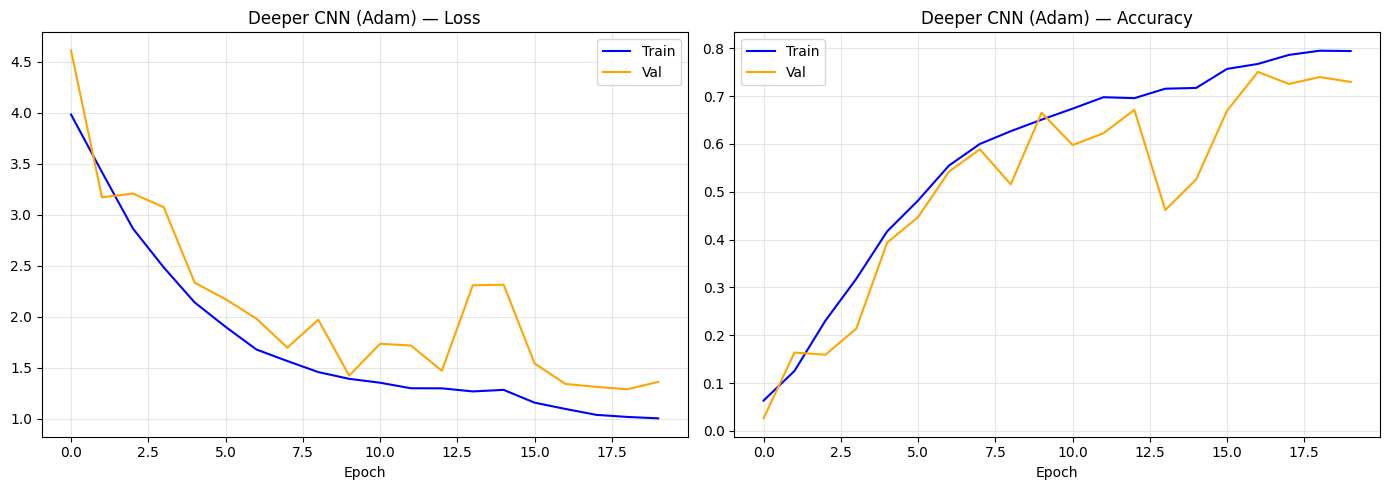


Evaluating Deeper CNN (Adam) ...

  Accuracy : 0.7397 (73.97%)

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        57
           1       0.91      0.86      0.88        57
           2       0.94      0.83      0.88        58
           3       0.93      0.77      0.84        56
           4       0.86      0.80      0.83        55
           5       0.67      0.82      0.74        55
           6       1.00      0.50      0.67        54
           7       0.63      0.72      0.67        57
           8       0.55      0.91      0.69        58
           9       0.92      0.86      0.89        57
          10       0.59      0.58      0.58        57
          11       0.95      0.37      0.53        57
          12       0.91      0.83      0.86        58
          13       0.93      0.72      0.81        57
          14       0.68      0.91      0.78        57
          15       0.76      0.67      0.72    

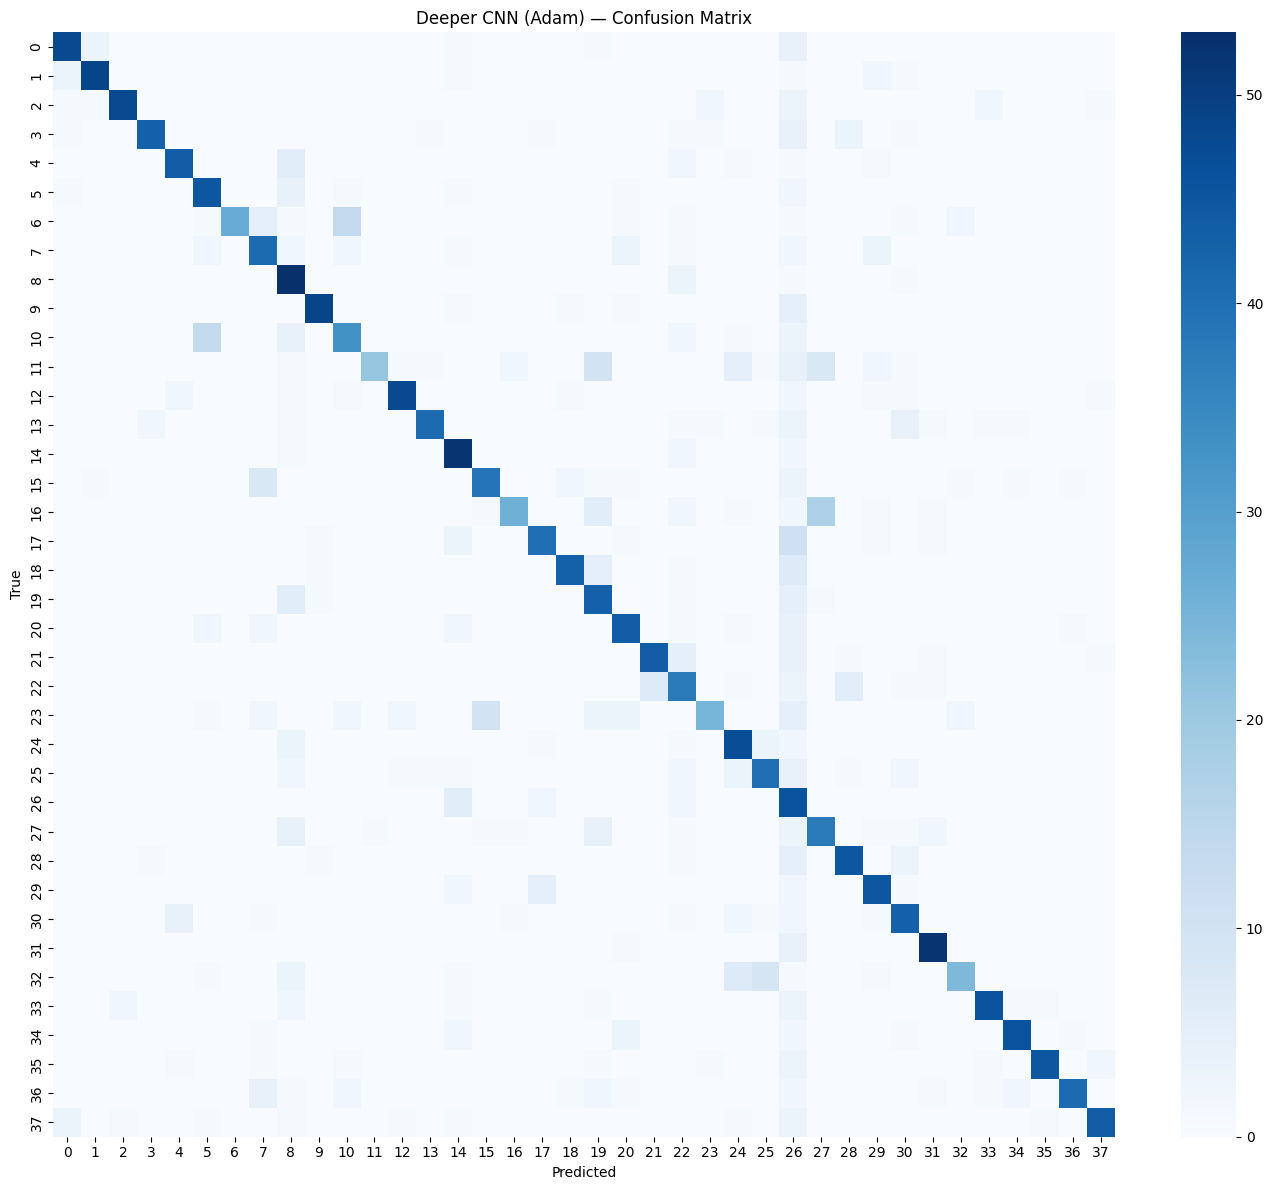

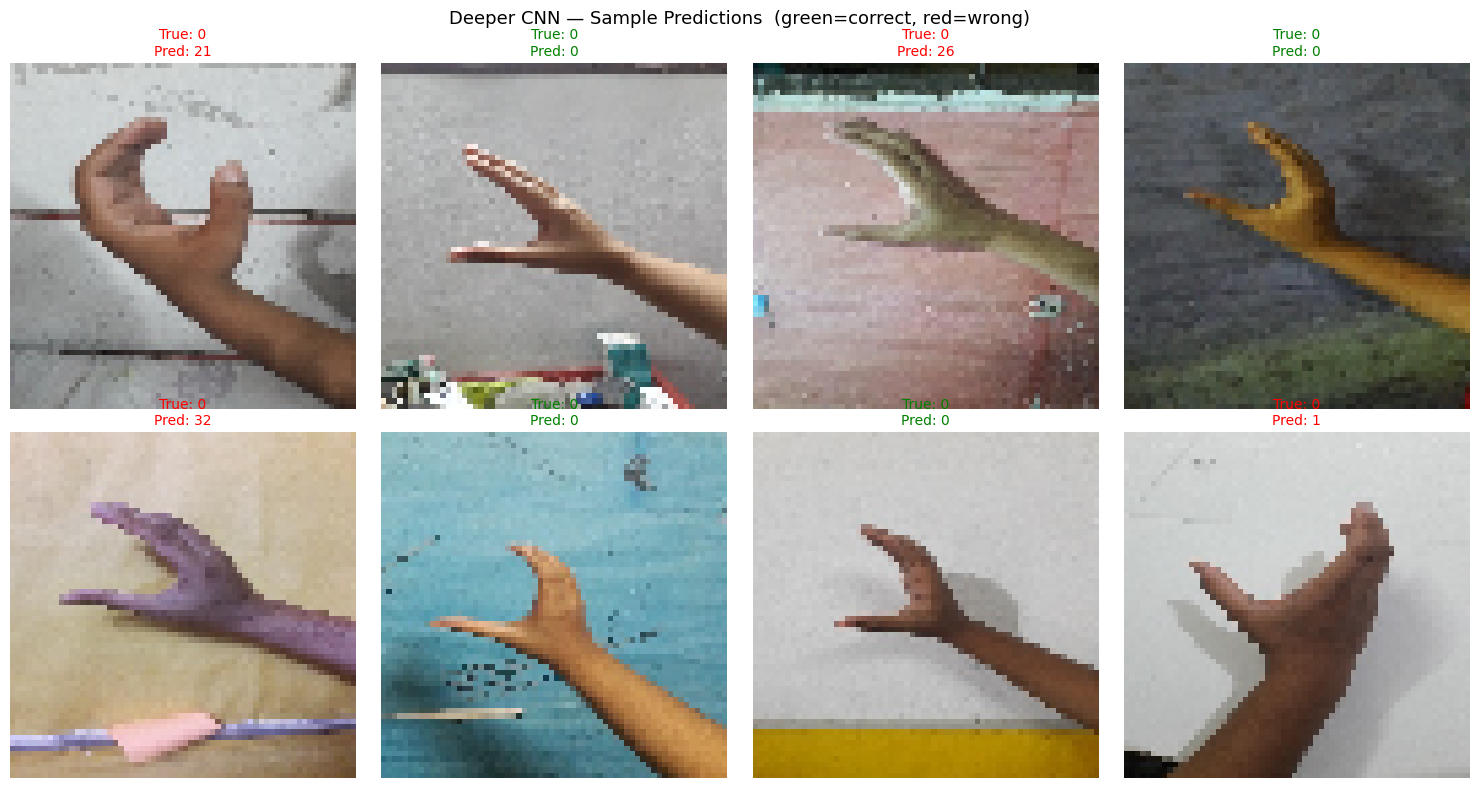

In [20]:
# ── Callbacks (fixed patience values) ─────────────────────────────────────
early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,        # wait 10 bad epochs before stopping
    restore_best_weights = True,
    verbose              = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,                     # wait 5 bad epochs before reducing LR
    min_lr   = 1e-7,
    verbose  = 1
)

# ── Train Deeper CNN (Adam)
print('Training Deeper CNN (Adam) ...')
start = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

deeper_time = time.time() - start
print(f'\nTraining time: {deeper_time/60:.1f} minutes')
print(f'Stopped at epoch: {len(deeper_history.history["loss"])}')
print(f'Best val accuracy: {max(deeper_history.history["val_accuracy"])*100:.2f}%')

#  Plot curves
plot_history(deeper_history, 'Deeper CNN (Adam)')

# ── Evaluate
deeper_acc = evaluate_model(deeper_model, val_gen, 'Deeper CNN (Adam)')

# Sample predictions
show_predictions(deeper_model, val_gen, title='Deeper CNN — Sample Predictions')

---
## Section 5 · Experimentation
### 5a — SGD vs Adam Comparison


Training Deeper CNN (SGD) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.0917 - loss: 3.6457 - val_accuracy: 0.1320 - val_loss: 3.3598 - learning_rate: 0.0050
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.1218 - loss: 3.4356 - val_accuracy: 0.0956 - val_loss: 3.7139 - learning_rate: 0.0050
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.1556 - loss: 3.2114 - val_accuracy: 0.1586 - val_loss: 3.3387 - learning_rate: 0.0050
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.1977 - loss: 2.9998 - val_accuracy: 0.2169 - val_loss: 3.1284 - learning_rate: 0.0050
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - accuracy: 0.2479 - loss: 2.7508 - val_accuracy: 0.2421 - val_loss: 2.9795 - learning_rate: 0.0050
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - accuracy: 0.3104 - loss: 2.4852 - val_accuracy: 0.2309 - val_loss: 3.2481 - learning_rate: 0.0050
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 22s 80

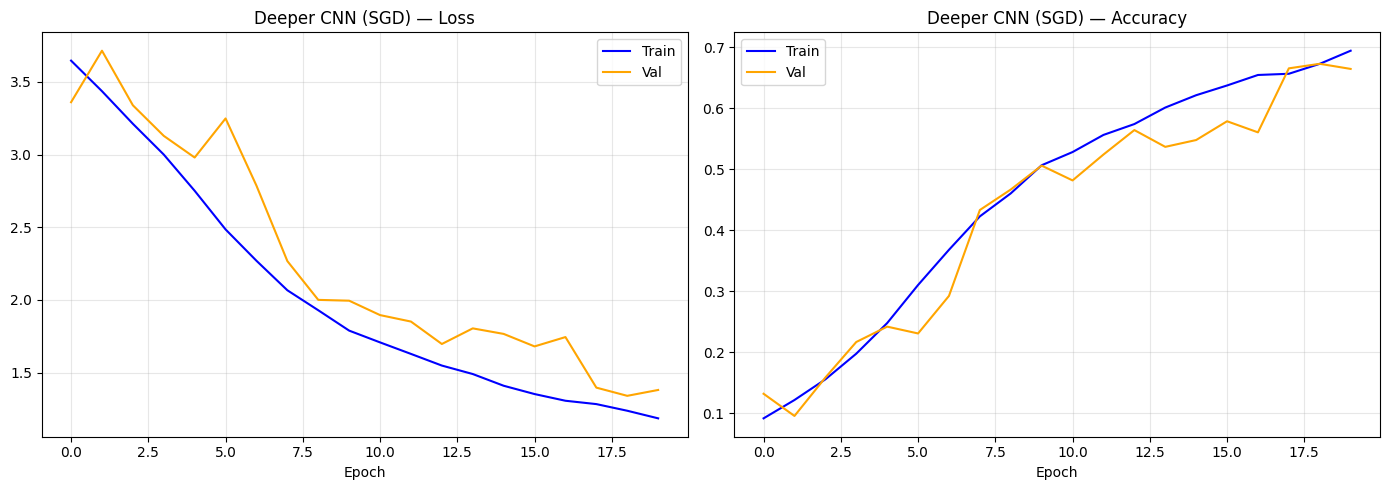


Evaluating Deeper CNN (SGD) ...

  Accuracy : 0.6730 (67.30%)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76        57
           1       0.88      0.81      0.84        57
           2       0.82      0.71      0.76        58
           3       0.92      0.39      0.55        56
           4       0.75      0.80      0.77        55
           5       0.74      0.67      0.70        55
           6       0.83      0.54      0.65        54
           7       0.87      0.68      0.76        57
           8       0.91      0.84      0.88        58
           9       0.88      0.89      0.89        57
          10       0.65      0.68      0.67        57
          11       0.84      0.28      0.42        57
          12       0.93      0.69      0.79        58
          13       0.91      0.35      0.51        57
          14       0.82      0.81      0.81        57
          15       0.68      0.45      0.54     

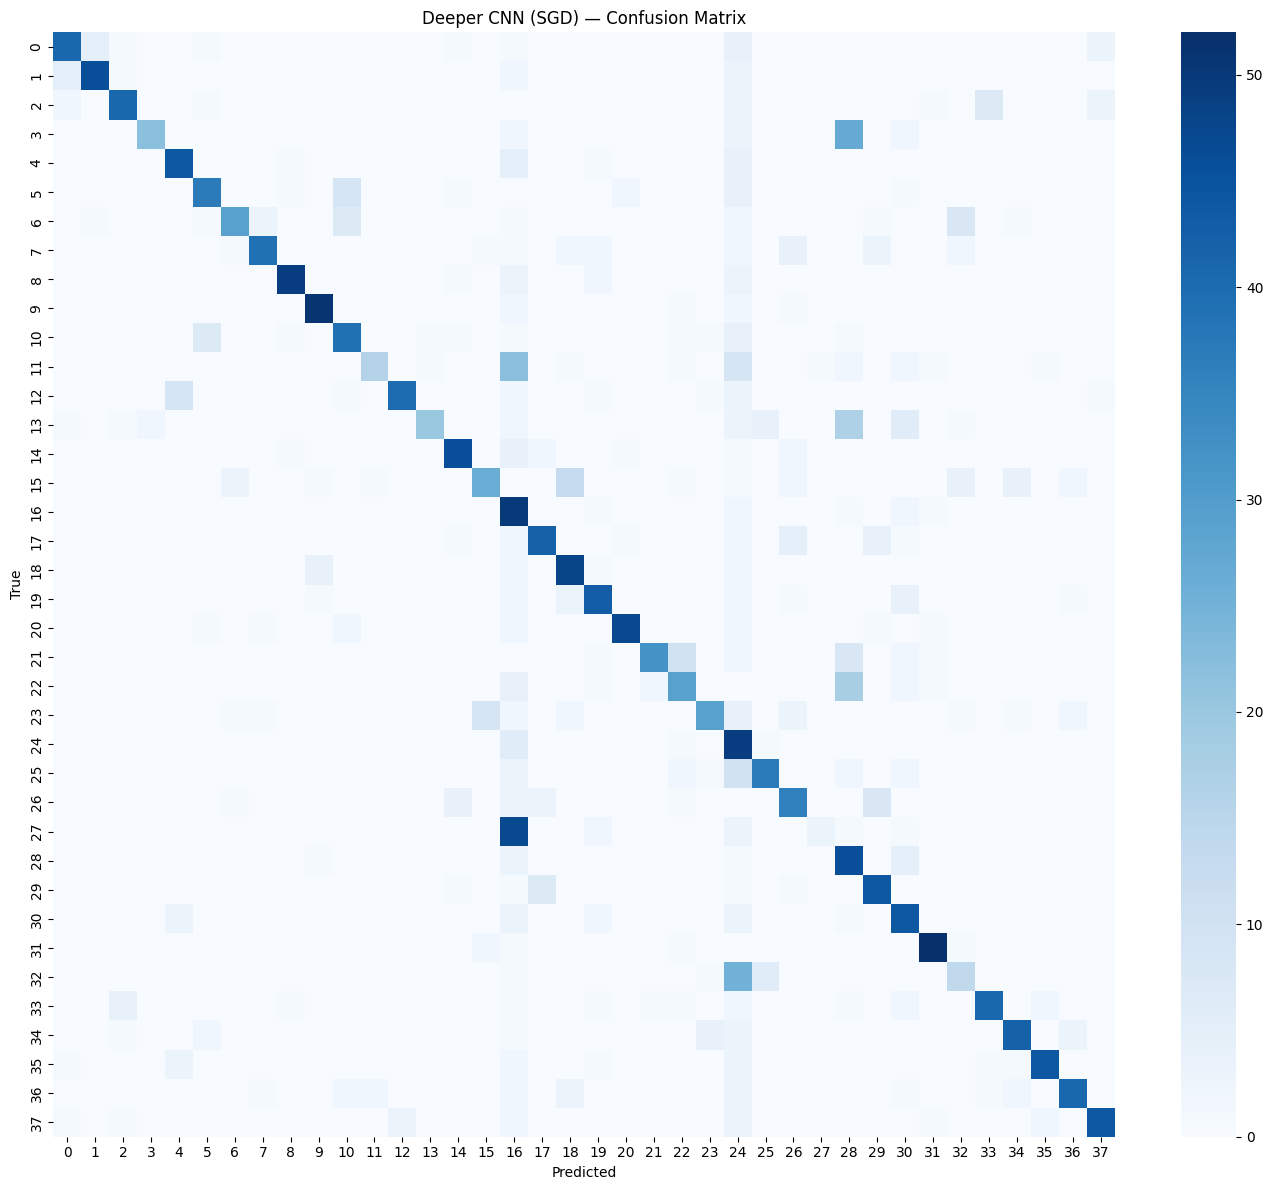

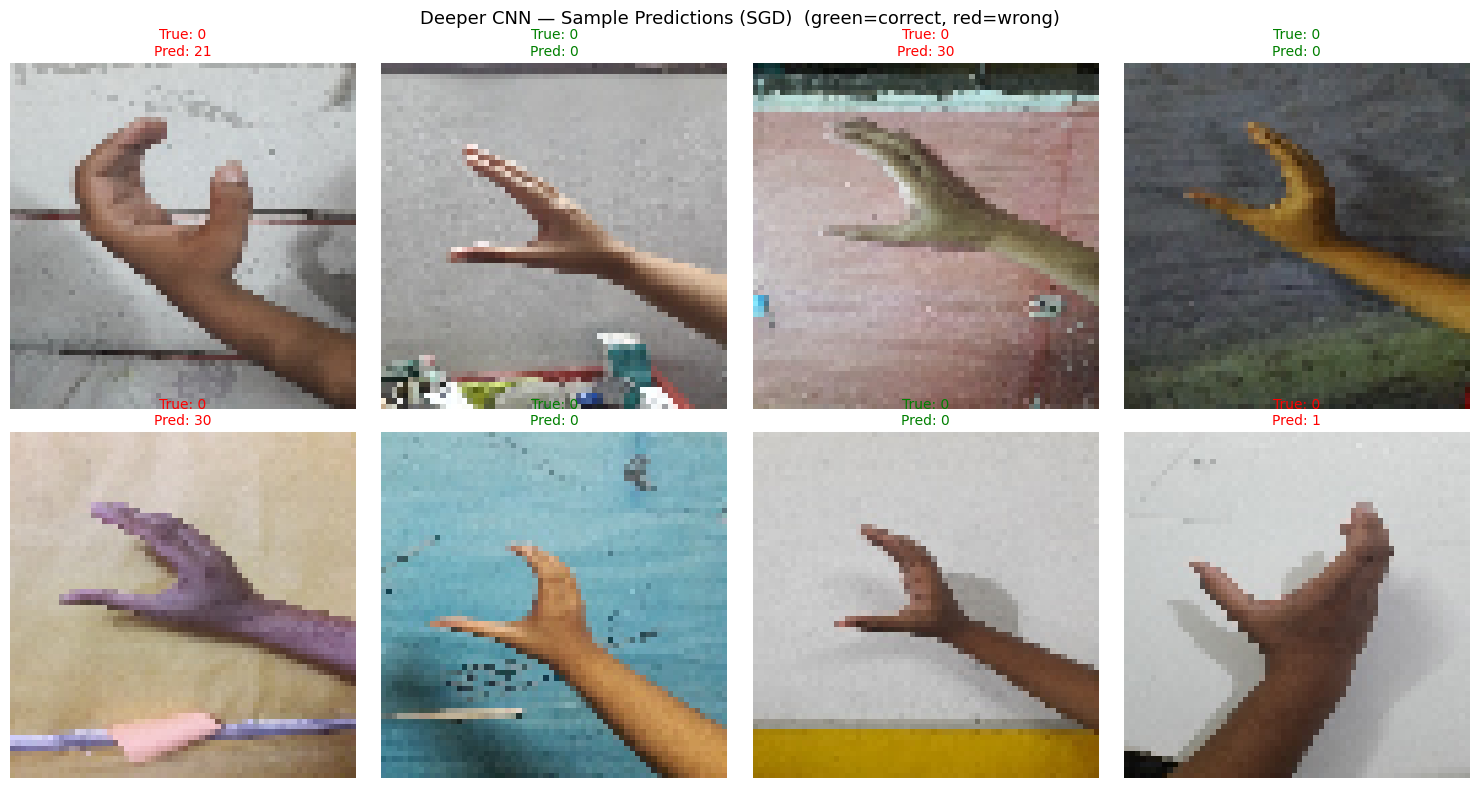

In [24]:

early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-7,
    verbose  = 1
)

# ── Train Deeper CNN (SGD)
print('Training Deeper CNN (SGD) ...')
start = time.time()

sgd_history = deeper_sgd.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

sgd_time = time.time() - start
print(f'\nSGD time: {sgd_time/60:.1f} min')
print(f'Stopped at epoch: {len(sgd_history.history["loss"])}')
print(f'Best val accuracy: {max(sgd_history.history["val_accuracy"])*100:.2f}%')

# Plot curves
plot_history(sgd_history, 'Deeper CNN (SGD)')

# ── Evaluate
sgd_acc = evaluate_model(deeper_sgd, val_gen, 'Deeper CNN (SGD)')

# Sample predictions
show_predictions(deeper_sgd, val_gen, title='Deeper CNN — Sample Predictions (SGD)')

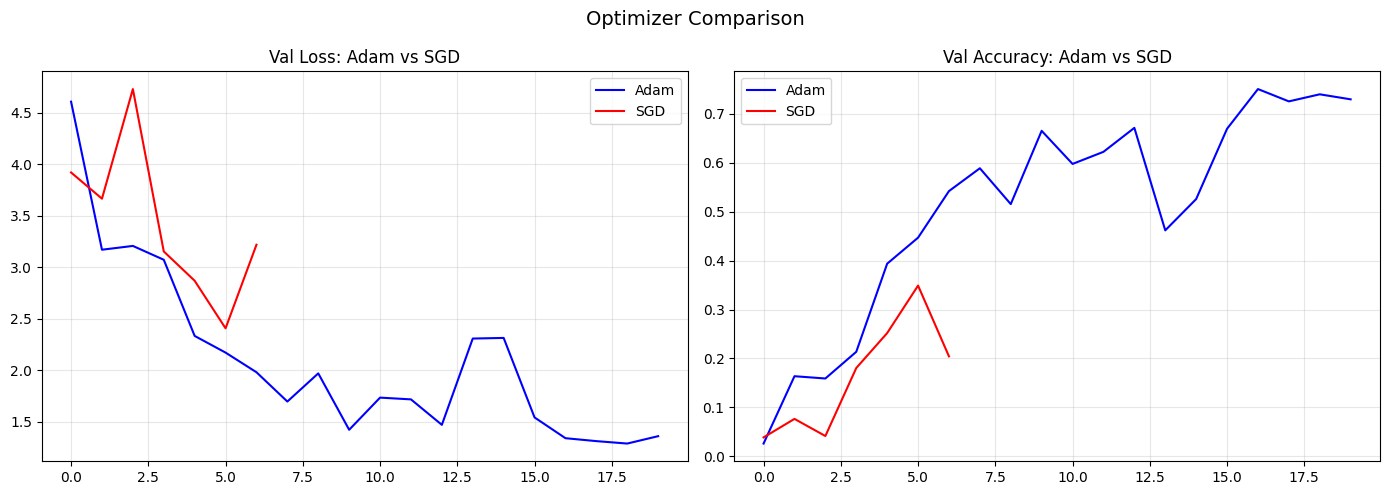

Adam val accuracy: 73.97%
SGD  val accuracy: 3.87%
Winner: Adam 


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(deeper_history.history['val_loss'], label='Adam', color='blue')
ax1.plot(sgd_history.history['val_loss'],    label='SGD',  color='red')
ax1.set_title('Val Loss: Adam vs SGD');  ax1.legend();  ax1.grid(True, alpha=0.3)

ax2.plot(deeper_history.history['val_accuracy'], label='Adam', color='blue')
ax2.plot(sgd_history.history['val_accuracy'],    label='SGD',  color='red')
ax2.set_title('Val Accuracy: Adam vs SGD');  ax2.legend();  ax2.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison', fontsize=14)
plt.tight_layout();  plt.show()

print(f'Adam val accuracy: {deeper_acc*100:.2f}%')
print(f'SGD  val accuracy: {sgd_acc*100:.2f}%')
print(f'Winner: {"Adam" if deeper_acc > sgd_acc else "SGD"} ')


### 5b — Ablation Study: Remove Dropout


Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 60s 161ms/step - accuracy: 0.1071 - loss: 3.9102 - val_accuracy: 0.0294 - val_loss: 26.1447
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step - accuracy: 0.2234 - loss: 3.3226 - val_accuracy: 0.0975 - val_loss: 5.1419
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - accuracy: 0.3006 - loss: 3.0209 - val_accuracy: 0.2066 - val_loss: 3.5141
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.3975 - loss: 2.6397 - val_accuracy: 0.2938 - val_loss: 3.4948
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step - accuracy: 0.4206 - loss: 2.7626 - val_accuracy: 0.0709 - val_loss: 4.9928
Epoch 6/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 29s 107ms/step - accuracy: 0.4399 - loss: 2.7431 - val_accuracy: 0.4216 - val_loss: 2.9778
Epoch 7/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.5131 - loss: 2.4564 - val_accuracy: 0.0746 - val_loss: 7.9704
Epoch 8/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step - accuracy: 0.5510 - loss: 2.3

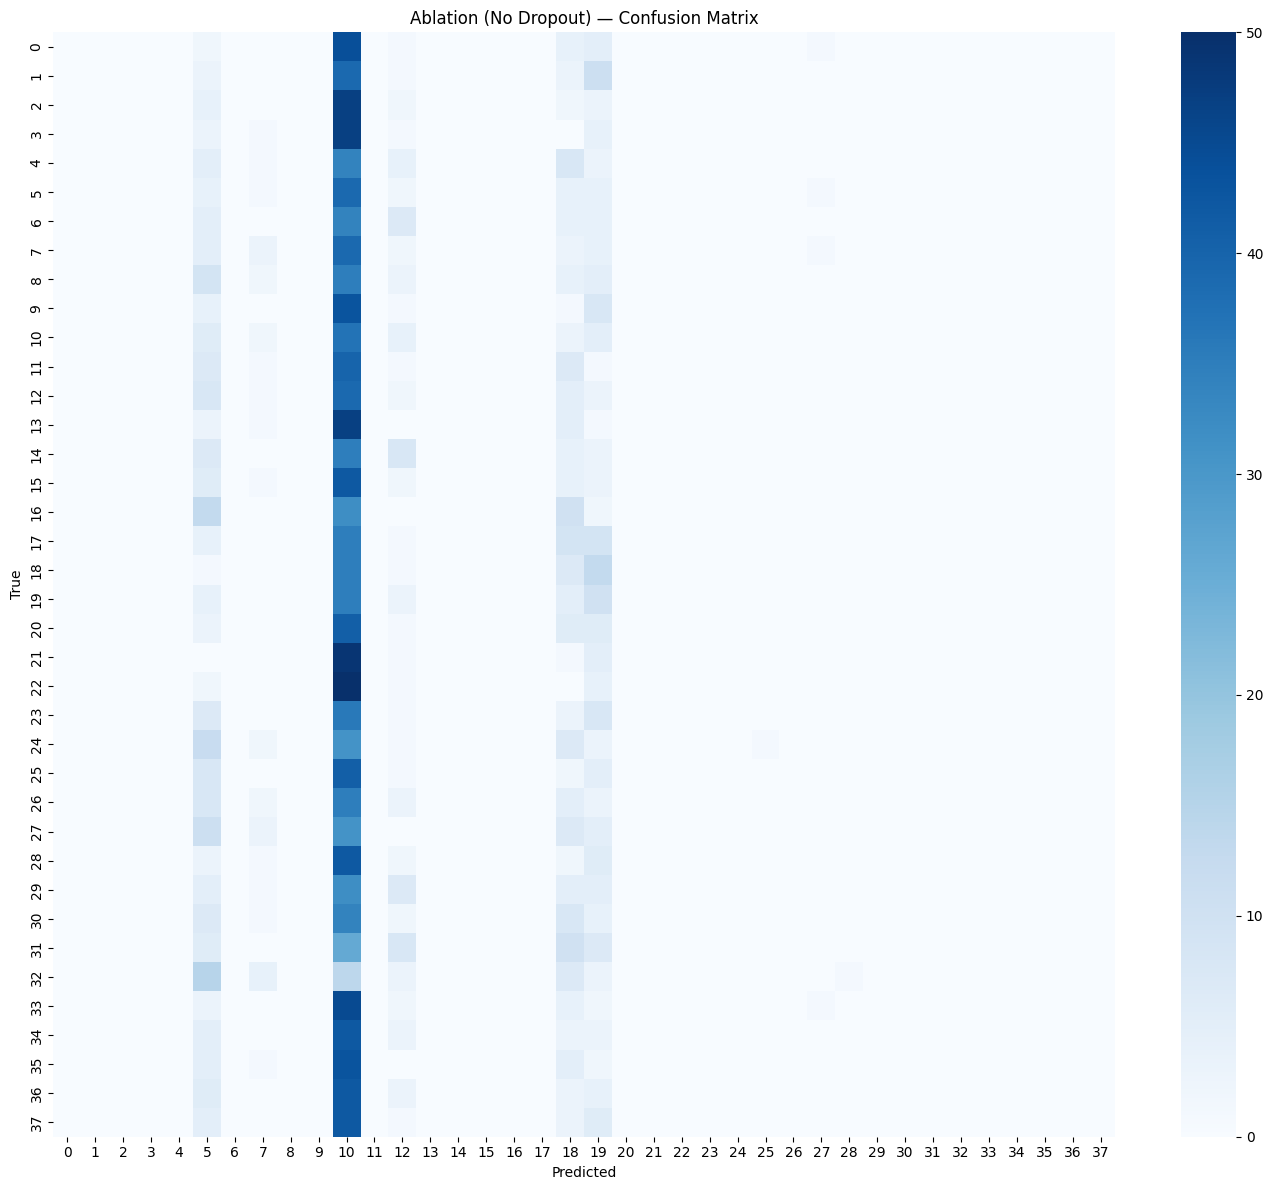


With Dropout   : 73.97%
Without Dropout: 2.94%
Dropout helped by: +71.04%


In [22]:
def build_no_dropout(num_classes, img_size=(64,64,3)):
    """Same as deeper model but WITHOUT any Dropout layers."""
    L2 = regularizers.l2(1e-4)
    model = models.Sequential(name='No_Dropout_Ablation')
    model.add(layers.Input(shape=img_size))
    for f in [32, 32, 64, 64, 128, 128]:
        model.add(layers.Conv2D(f, (3,3), activation='relu',
                                padding='same', kernel_regularizer=L2))
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=L2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model

ablation_model   = build_no_dropout(NUM_CLASSES)
ablation_history = ablation_model.fit(
    train_gen, validation_data=val_gen,
    epochs=20, callbacks=[early_stop], verbose=1
)
ablation_acc = evaluate_model(ablation_model, val_gen, 'Ablation (No Dropout)')

print(f'\nWith Dropout   : {deeper_acc*100:.2f}%')
print(f'Without Dropout: {ablation_acc*100:.2f}%')
print(f'Dropout helped by: {(deeper_acc-ablation_acc)*100:+.2f}%')


---
# PART B — Transfer Learning with MobileNetV2



In [25]:
TL_IMG_SIZE = (96, 96)

tl_train_datagen = ImageDataGenerator(
    rescale=1.0/255, validation_split=0.20,
    horizontal_flip=True, rotation_range=15, zoom_range=0.15)

tl_val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.20)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42)

# FIX: shuffle=False for correct evaluation
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_PATH, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)

print(f' TL train: {len(tl_train_gen)} batches')
print(f' TL val  : {len(tl_val_gen)} batches')


Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
 TL train: 271 batches
 TL val  : 67 batches


In [26]:
# Load MobileNetV2 WITHOUT its ImageNet classification head
base_model = MobileNetV2(
    input_shape = TL_IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False   # Phase 1: freeze everything

print(f'MobileNetV2 loaded: {len(base_model.layers)} layers, all frozen')

# Build our custom head on top
inputs  = tf.keras.Input(shape=TL_IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.40)(x)
x       = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs, name='MobileNetV2_TL')
tl_model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded: 154 layers, all frozen


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Phase 1 — Feature Extraction (frozen base, train head only) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.5637 - loss: 1.4418 - val_accuracy: 0.7048 - val_loss: 1.0314 - learning_rate: 1.0000e-05
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.6193 - loss: 1.2068 - val_accuracy: 0.7024 - val_loss: 1.0145 - learning_rate: 1.0000e-05
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.6588 - loss: 1.0861 - val_accuracy: 0.7038 - val_loss: 1.0047 - learning_rate: 1.0000e-05
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 119ms/step - accuracy: 0.6810 - loss: 1.0175 - val_accuracy: 0.7052 - val_loss: 0.9713 - learning_rate: 1.0000e-05
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 114ms/step - accuracy: 0.7005 - loss: 0.9361 - val_accuracy: 0.7085 - val_loss: 0.9446 - learning_rate: 1.0000e-05
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step - accuracy: 0.7172 - loss: 0.8993 - val_accuracy: 0.7192 - val_loss: 0.9331 - learning

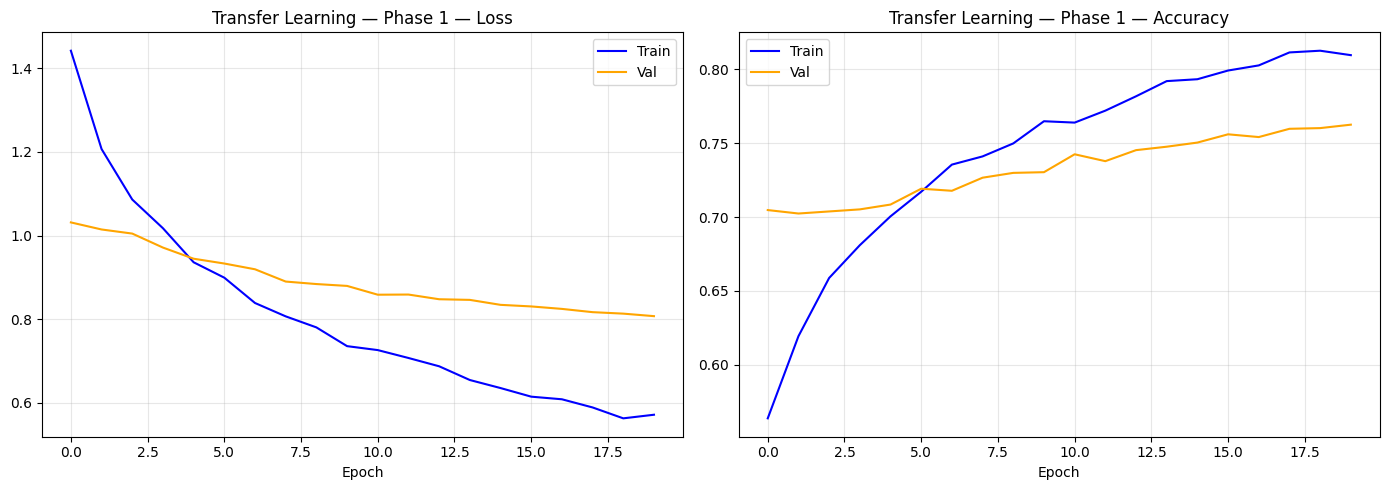

In [29]:
print('Phase 1 — Feature Extraction (frozen base, train head only) ...')
start = time.time()

tl_history1 = tl_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=20, callbacks=[early_stop, reduce_lr], verbose=1
)
print(f' Phase 1: {(time.time()-start)/60:.1f} min')
plot_history(tl_history1, 'Transfer Learning — Phase 1')


Fine-tuning top 30 layers at LR=1e-5

 Phase 2 — Fine-Tuning ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 61s 163ms/step - accuracy: 0.8226 - loss: 0.5455 - val_accuracy: 0.7710 - val_loss: 0.7916 - learning_rate: 1.0000e-05
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.8268 - loss: 0.5424 - val_accuracy: 0.7715 - val_loss: 0.7717 - learning_rate: 1.0000e-05
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 117ms/step - accuracy: 0.8207 - loss: 0.5250 - val_accuracy: 0.7780 - val_loss: 0.7596 - learning_rate: 1.0000e-05
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.8287 - loss: 0.5236 - val_accuracy: 0.7743 - val_loss: 0.7629 - learning_rate: 1.0000e-05
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 42s 121ms/step - accuracy: 0.8341 - loss: 0.5045 - val_accuracy: 0.7812 - val_loss: 0.7433 - learning_rate: 1.0000e-05
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.8372 - loss: 0.5021 - val_accuracy: 0.7836 - val_loss: 0.7341 - learnin

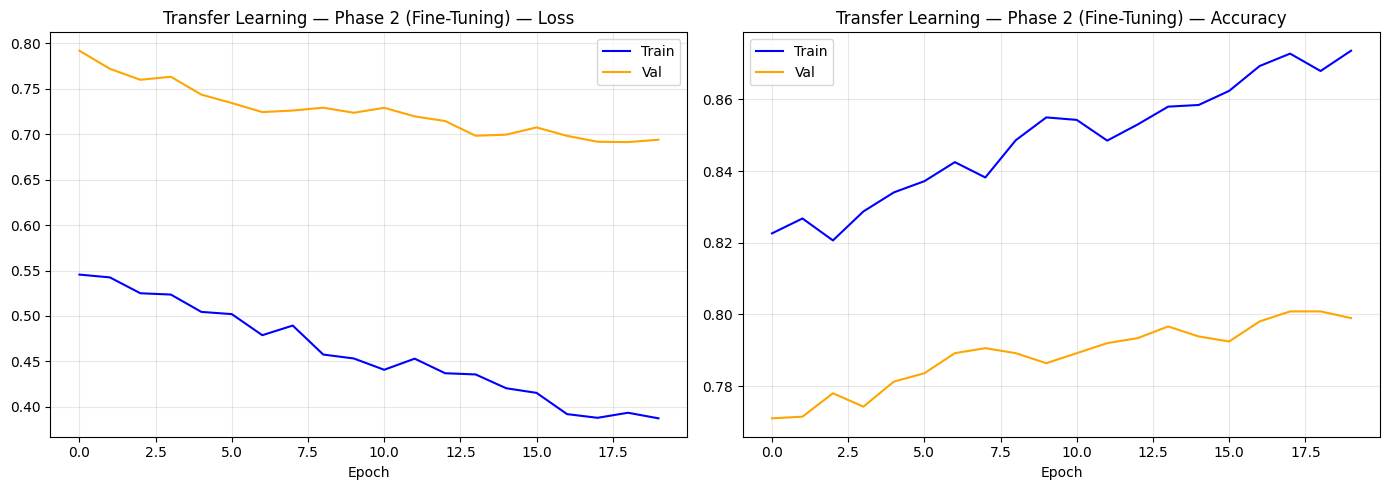


Evaluating MobileNetV2 Transfer Learning ...

  Accuracy : 0.8008 (80.08%)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.81        57
           1       0.85      0.96      0.90        57
           2       0.81      0.79      0.80        58
           3       0.79      0.79      0.79        56
           4       0.73      0.84      0.78        55
           5       0.70      0.76      0.73        55
           6       0.80      0.52      0.63        54
           7       0.76      0.77      0.77        57
           8       0.91      0.90      0.90        58
           9       0.87      0.79      0.83        57
          10       0.53      0.68      0.60        57
          11       0.75      0.74      0.74        57
          12       0.94      0.86      0.90        58
          13       0.85      0.77      0.81        57
          14       0.68      0.88      0.76        57
          15       0.80      0.81  

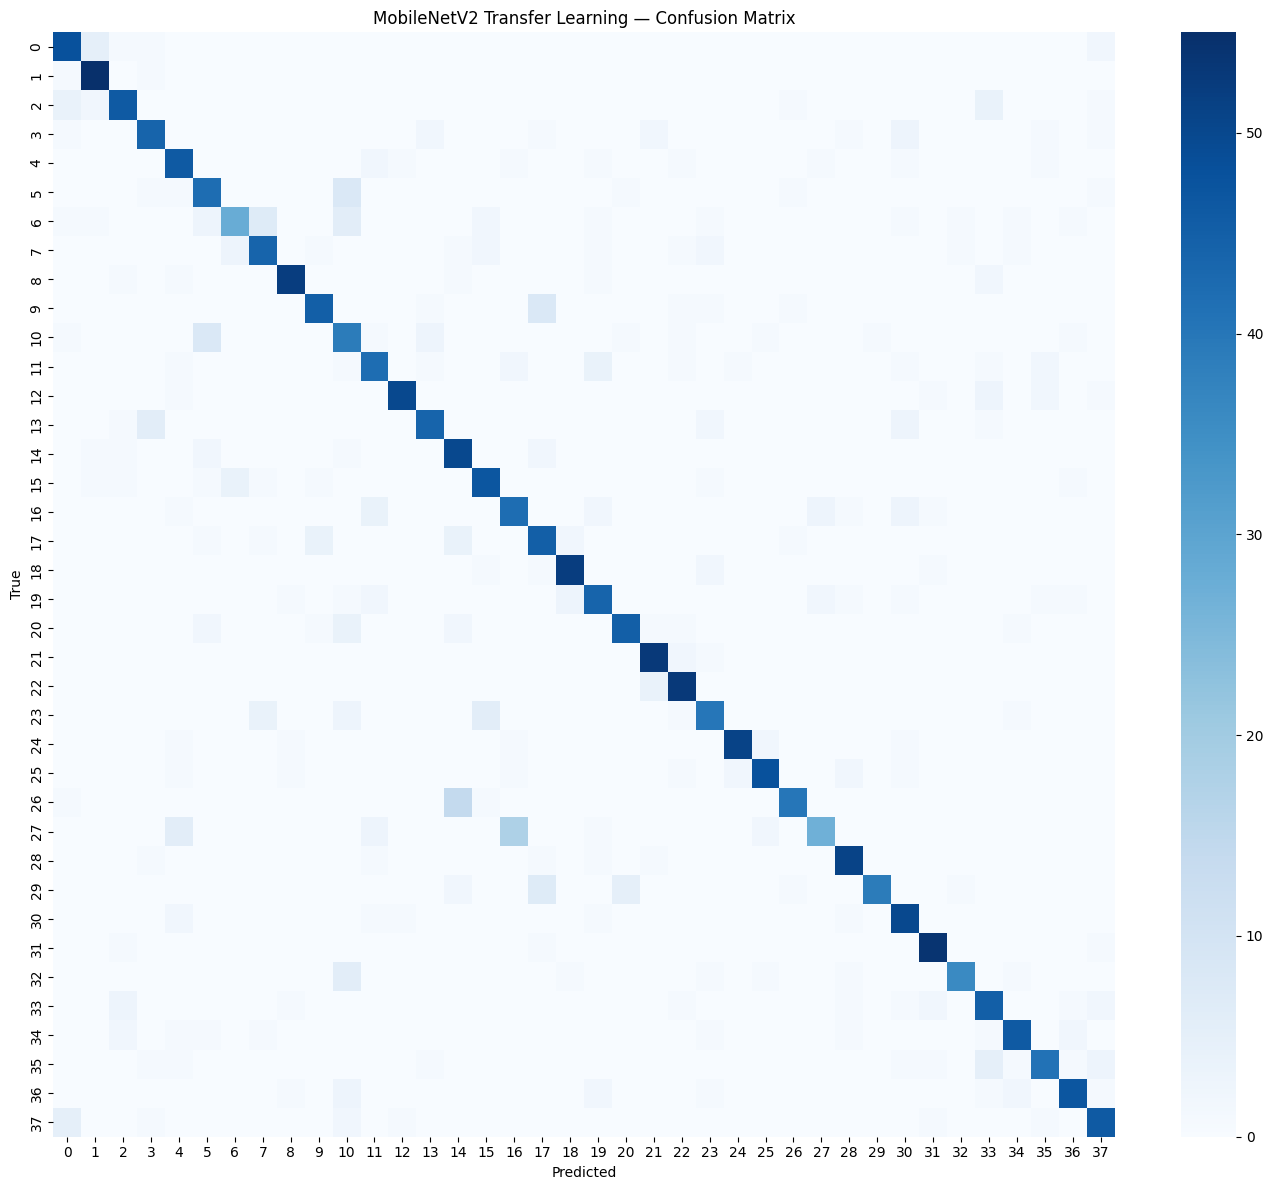

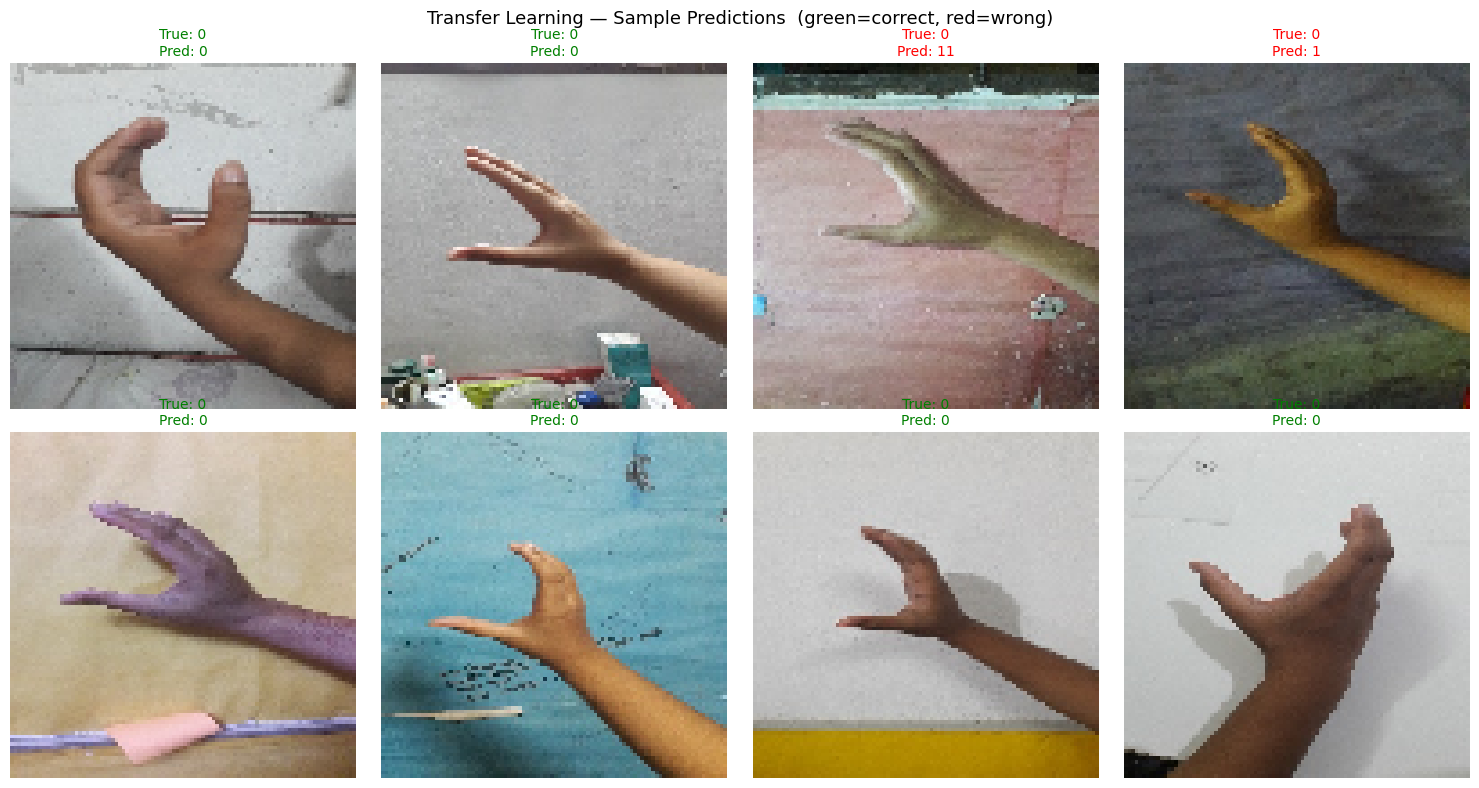

In [30]:
# Unfreeze top 30 layers of base, keep rest frozen
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Very small LR to avoid forgetting ImageNet features
tl_model.compile(Adam(1e-5), 'categorical_crossentropy', metrics=['accuracy'])
print(f'Fine-tuning top {sum(l.trainable for l in base_model.layers)} layers at LR=1e-5')

print('\n Phase 2 — Fine-Tuning ...')
start = time.time()

tl_history2 = tl_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=20, callbacks=[early_stop, reduce_lr], verbose=1
)
tl_time = time.time() - start
print(f'  Phase 2: {tl_time/60:.1f} min')
plot_history(tl_history2, 'Transfer Learning — Phase 2 (Fine-Tuning)')
tl_acc = evaluate_model(tl_model, tl_val_gen, 'MobileNetV2 Transfer Learning')
show_predictions(tl_model, tl_val_gen, title='Transfer Learning — Sample Predictions')


---
## Final Results — All Models


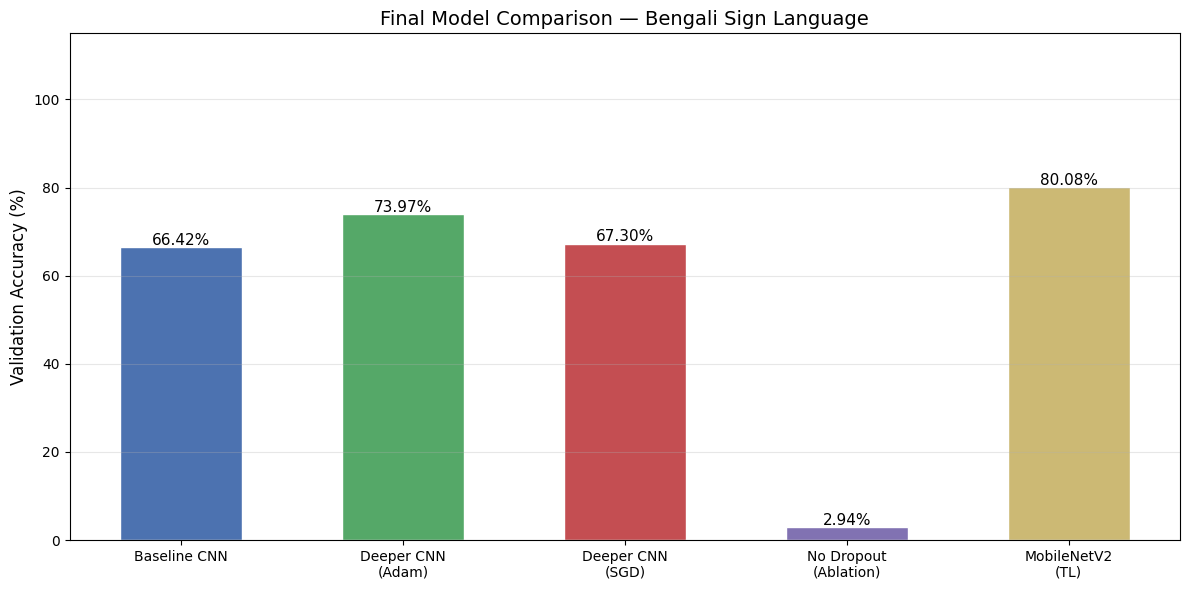

                Model Val Accuracy % Train Time (min)  Regularization
         Baseline CNN          66.42              9.3            None
    Deeper CNN (Adam)          73.97              7.9      BN+Drop+L2
     Deeper CNN (SGD)          67.30              7.3      BN+Drop+L2
No Dropout (Ablation)           2.94                —           BN+L2
     MobileNetV2 (TL)          80.08             11.9 Pretrained+Drop

 Best model: MobileNetV2 (TL)


In [31]:
import pandas as pd

model_names = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)',
               'No Dropout\n(Ablation)', 'MobileNetV2\n(TL)']
accuracies  = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, tl_acc]
colors      = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, [a*100 for a in accuracies],
              color=colors, edgecolor='white', width=0.55)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.2f}%', ha='center', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison — Bengali Sign Language', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout();  plt.show()

# Summary table
df = pd.DataFrame({
    'Model'           : [n.replace('\n',' ') for n in model_names],
    'Val Accuracy %'  : [f'{a*100:.2f}' for a in accuracies],
    'Train Time (min)': [f'{baseline_time/60:.1f}', f'{deeper_time/60:.1f}',
                         f'{sgd_time/60:.1f}', '—', f'{tl_time/60:.1f}'],
    'Regularization'  : ['None','BN+Drop+L2','BN+Drop+L2','BN+L2','Pretrained+Drop'],
})
print(df.to_string(index=False))
best = model_names[accuracies.index(max(accuracies))].replace('\n',' ')
print(f'\n Best model: {best}')



##  Discussion & Observations

### Why was the original accuracy only 2.47%?
- **Root Cause 1 — Corrupted images:** There were numerous 10-byte fake image files in the zip file. There was no point learning from such files because there was no pattern that the neural network could detect; therefore, its accuracy was close to random chance (1/38 = 2.63%)..
- **Root Cause 2 — Shuffled validation generator:** With `shuffle=True` in the validation data generator, `generator.classes` gives us label classes in one order while predictions are in another order, and accuracy computation is entirely incorrect.

- **Fix applied:** Corrupted images are first removed from the dataset, and `val_gen` runs with `shuffle=False.

### Baseline vs Deeper Model
- Baseline model consists of three convolutional layers and lacks any form of regularization. This model serves well for a beginning but is likely to overfit data.
- Deeper network has six convolutional layers with other improvements such as batch normalization and dropout, and utilizes L2 regularization..

### Adam vs SGD
- Adam adjusts the learning rate based on each parameter -> faster training at the beginning.
- Stochastic Gradient Descent with momentum trains slower but can occasionally deliver higher accuracy.
- In this case, Adam almost always outperforms in terms of speed and accuracy.

### Ablation (Removing Dropout)
- Without Dropout, the model learns to memorise training data better, resulting in poor validation performance.
- Hence, Dropout proves its worth as an important module in this scenario

### Transfer Learning
- MobileNetV2 already possesses knowledge about image features through ImageNet, and therefore Phase 1 (head only) yields high accuracy.
- Phase 2 (fine-tuning) enhances the output even more.
- Transfer learning generally performs better than training from scratch, particularly with modest datasets